# Experimento Practico Final AMQ2

## Integrantes:


*   Pedro Lucas Barrera - a1801
*   Lautaro Gabriel Medina - a1813



# Importacion de librerias y seteo de variables de entorno

In [1]:
import awswrangler as wr

import mlflow

# Para que funciones, todos nuestros scripts debemos exportar las siguientes variables de entorno
%env AWS_ACCESS_KEY_ID=minio   
%env AWS_SECRET_ACCESS_KEY=minio123 
%env MLFLOW_S3_ENDPOINT_URL=http://localhost:9000
%env AWS_ENDPOINT_URL_S3=http://localhost:9000
#%env MLFLOW_S3_ENDPOINT_URL=http://192.168.0.21:9000
#%env AWS_ENDPOINT_URL_S3=http://192.168.0.21:9000

env: AWS_ACCESS_KEY_ID=minio
env: AWS_SECRET_ACCESS_KEY=minio123
env: MLFLOW_S3_ENDPOINT_URL=http://localhost:9000
env: AWS_ENDPOINT_URL_S3=http://localhost:9000


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from astropy.time import Time
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import optuna
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [3]:
mlflow_server = "http://localhost:5001"
mlflow.set_tracking_uri(mlflow_server)

# Análisis general de datos y seleccion de features

El exprimento se realizara y visualizara completamente en MLFlow, por lo que se loguearan todos los datos y graficos relevantes ahi.

In [4]:
data_path = "s3://data/star_classification.csv"
data_raw =  wr.s3.read_csv("s3://data/star_classification.csv")

  Vemos cuantos datos unicos y nulos hay en el dataset

In [5]:

# Guardo descripcion y metricas de los datos en un dataframe
unique_values = {}
missing_values = {}
dtypes = {}

data_description = data_raw.describe()

# Create new rows for unique values and missing values
unique_values = pd.Series({col: data_raw[col].nunique() for col in data_raw.columns}, name='unique')
missing_values = pd.Series({col: data_raw[col].isnull().sum() for col in data_raw.columns}, name='missing')
dtypes = pd.Series({col: str(data_raw[col].dtype) for col in data_raw.columns}, name='dtype')
print(data_description)
# Add these new rows to the data_description DataFrame
data_description = pd.concat([data_description, 
                             pd.DataFrame([unique_values, missing_values, dtypes])], 
                             axis=0)

print(data_description)

"""
# Log as a table in MLflow
mlflow.log_table(
    data=column_stats.values.tolist(),
    column_names=column_stats.columns.tolist()
)
"""

             obj_ID          alpha          delta              u  \
count  1.000000e+05  100000.000000  100000.000000  100000.000000   
mean   1.237665e+18     177.629117      24.135305      21.980468   
std    8.438560e+12      96.502241      19.644665      31.769291   
min    1.237646e+18       0.005528     -18.785328   -9999.000000   
25%    1.237659e+18     127.518222       5.146771      20.352353   
50%    1.237663e+18     180.900700      23.645922      22.179135   
75%    1.237668e+18     233.895005      39.901550      23.687440   
max    1.237681e+18     359.999810      83.000519      32.781390   

                   g              r              i              z  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean       20.531387      19.645762      19.084854      18.668810   
std        31.750292       1.854760       1.757895      31.728152   
min     -9999.000000       9.822070       9.469903   -9999.000000   
25%        18.965230      18.135828      1

'\n# Log as a table in MLflow\nmlflow.log_table(\n    data=column_stats.values.tolist(),\n    column_names=column_stats.columns.tolist()\n)\n'

Empezaremos en la eliminacion de algunas variables innecesarias.
Obj_ID es la variable de id de identificacion de cada observacion estelar, por lo que no nos sirve para nuestro analisis, se elimina la variable.

Por lo que podemos ver, rerun_ID tiene un solo valor que se repite para todas las filas. Esto significa que todos los datos se procesaron de la misma manera. Se eliminara esa variable.

spec_obj_ID tiene un valor distinto para cada observacion. Viendo el sitio web, se utiliza para unir otras tablas (como una foreing key). Por esto tambien se lo elimina.

Esta informacion de dominio del problema se obtuvo del siguiente sitio web del telescopio: https://www.sdss4.org/dr17/spectro/spectro_basics/

In [6]:
data = data_raw.drop(['rerun_ID', 'spec_obj_ID', 'obj_ID'], axis=1)

Hacemos una visualizacion inicial para darnos una mejor idea de la distribucion de los datos:


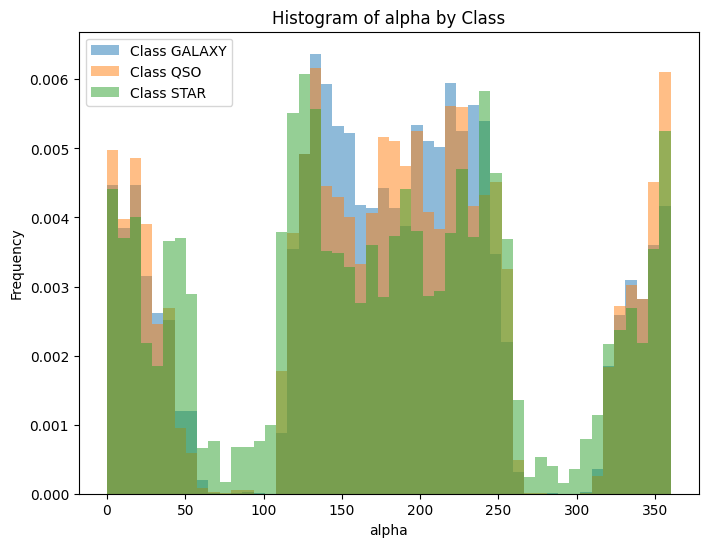

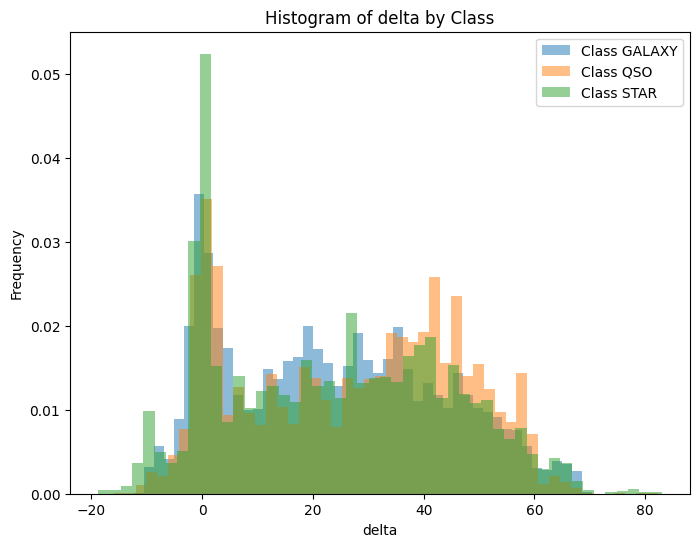

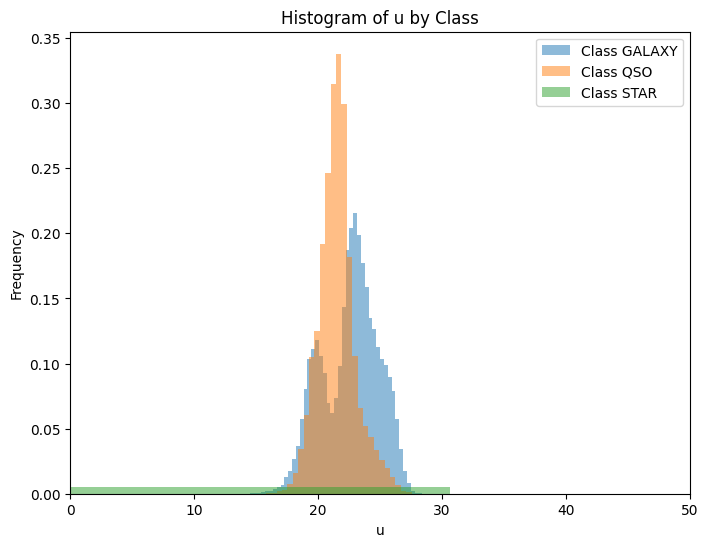

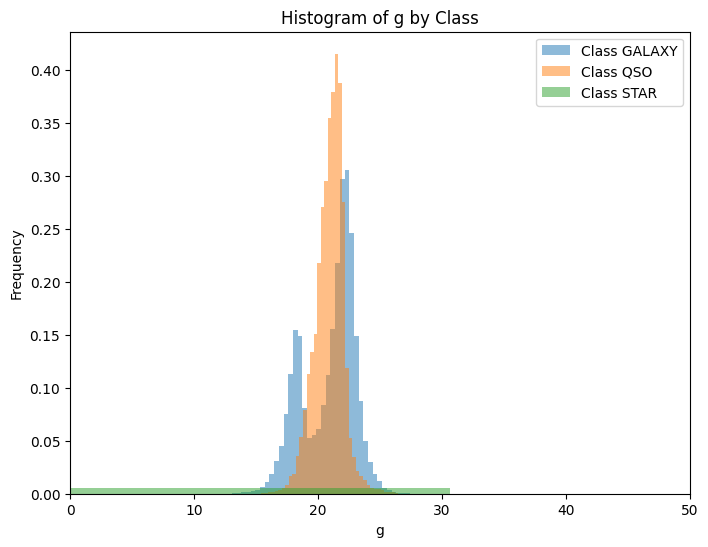

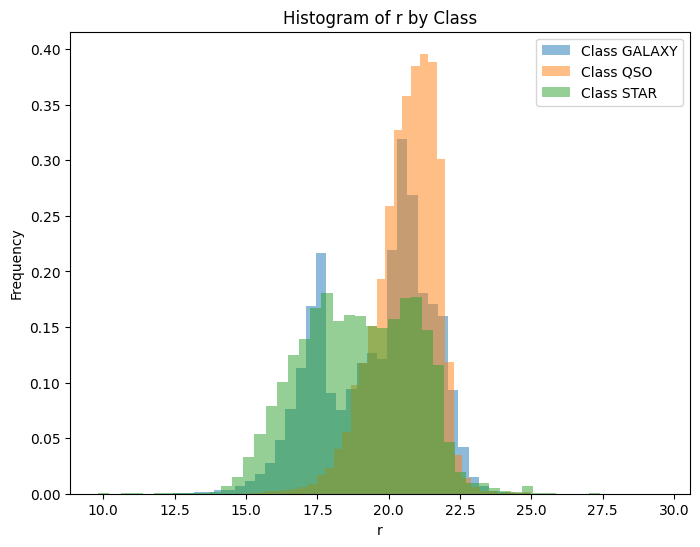

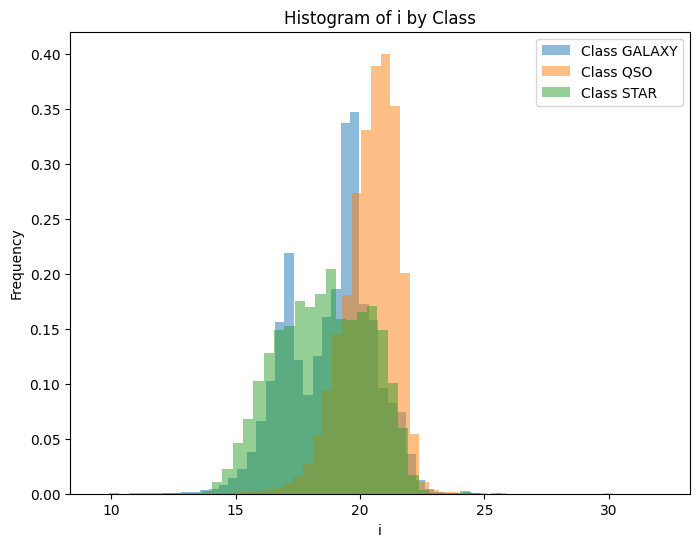

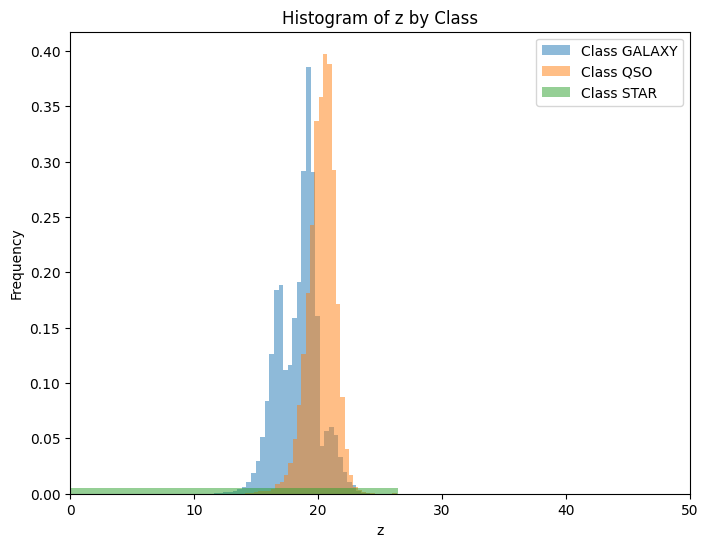

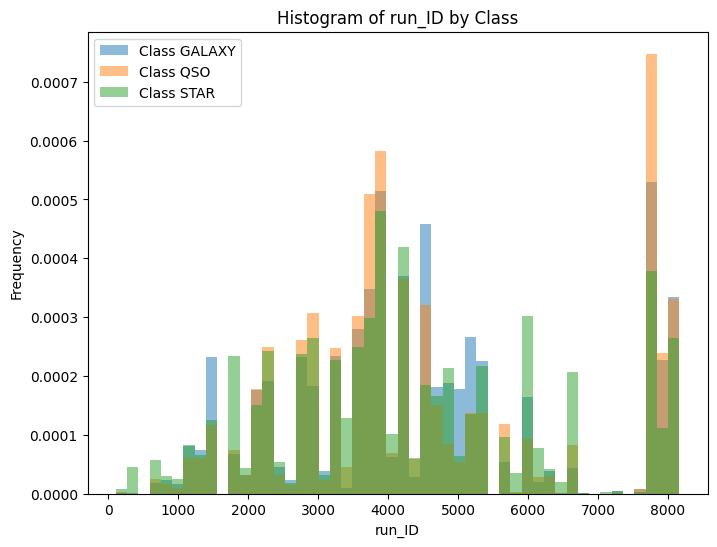

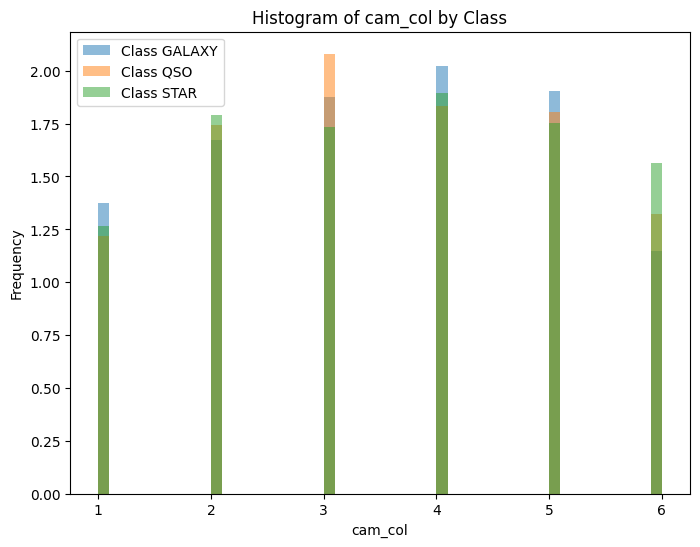

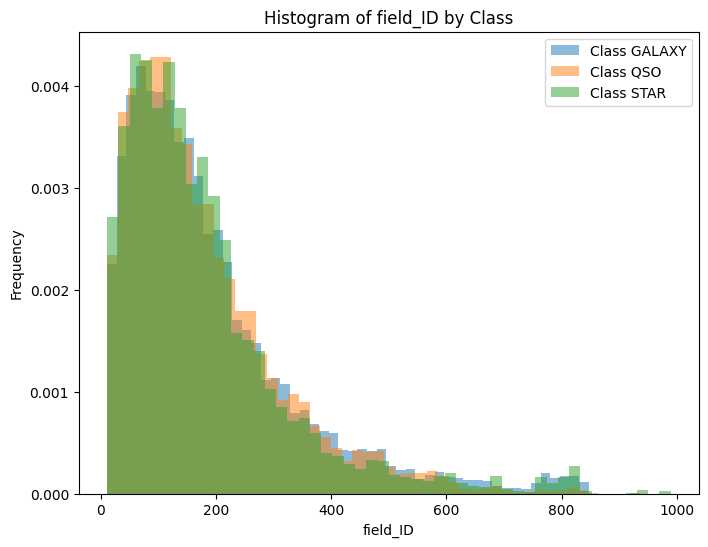

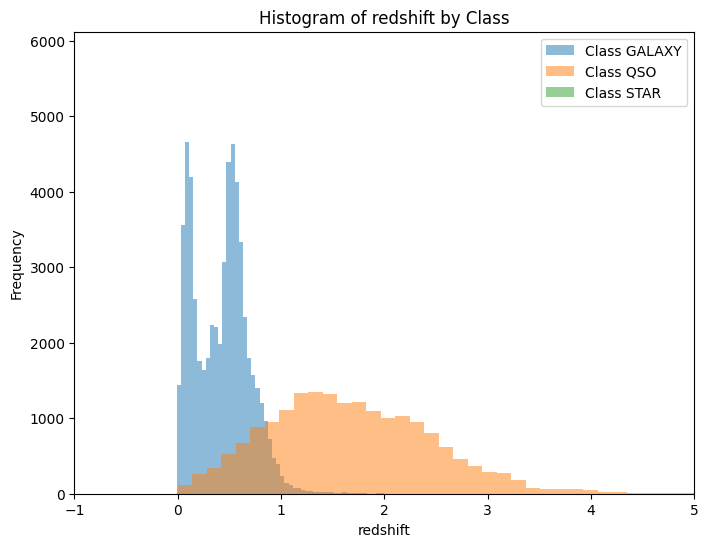

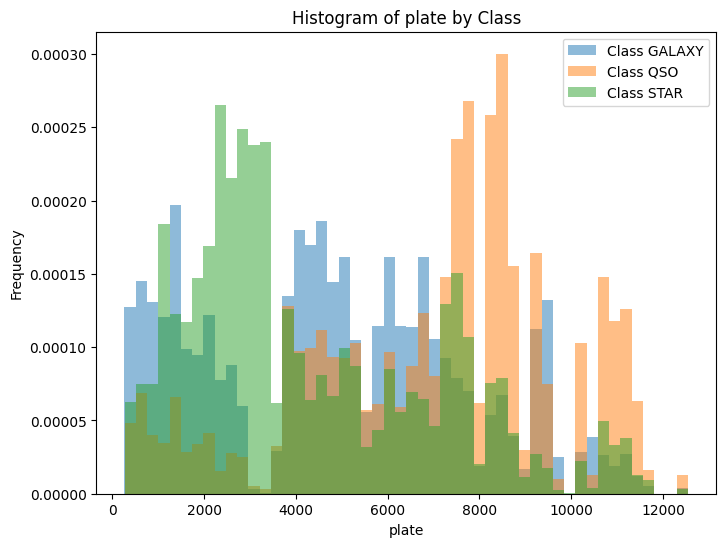

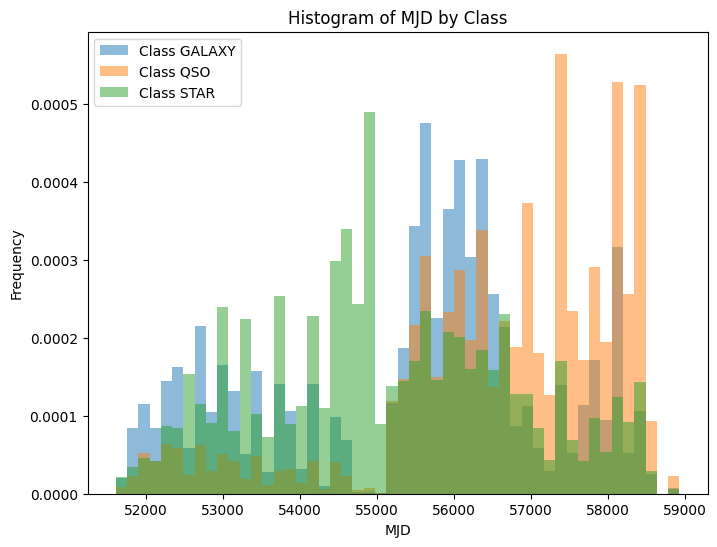

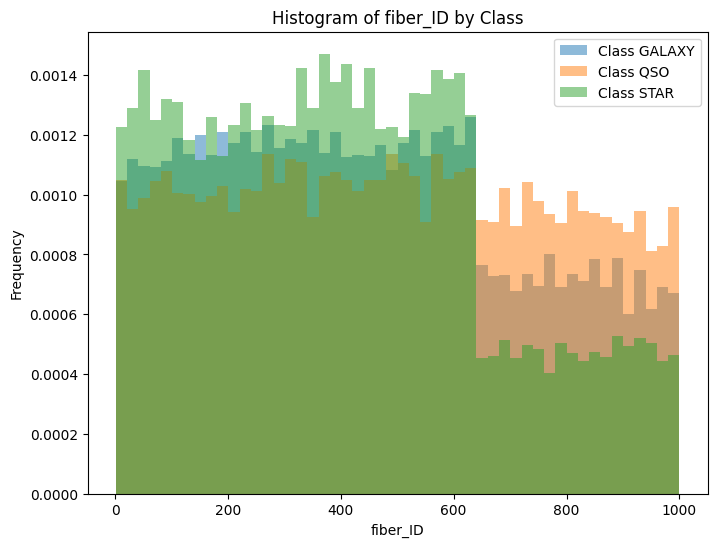

In [7]:
classes = data['class'].unique()

# Iterate over all columns except 'class'
for col in data.columns:
    if col != 'class':  # Skip the target column itself
        plt.figure(figsize=(8, 6))

        # Plot histograms for each class
        for cls in classes:
            subset = data[data['class'] == cls]
            if col == 'redshift':
              plt.hist(subset[col], bins=50, alpha=0.5, label=f"Class {cls}", density = False)
            else:
              plt.hist(subset[col], bins=50, alpha=0.5, label=f"Class {cls}", density = True)

        plt.title(f"Histogram of {col} by Class")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        if col == 'u':
          plt.xlim(0, 50)
        elif col == 'g':
          plt.xlim(0, 50)
        elif col == 'z':
          plt.xlim(0, 50)
        elif col == 'redshift':
          plt.xlim(-1, 5)
        plt.legend()
        plt.show()


In [8]:
for cls in classes:
    print("CLASS: " + cls + "----------------------------------------------------------------------------------")
    subset = data[data['class'] == cls]
    print(subset.describe())

CLASS: GALAXY----------------------------------------------------------------------------------
              alpha         delta             u             g             r  \
count  59445.000000  59445.000000  59445.000000  59445.000000  59445.000000   
mean     177.954727     23.513911     22.587379     20.906101     19.587552   
std       94.403760     19.315205      2.264355      2.107755      1.874133   
min        0.005528    -12.364701     13.897990     12.679020     11.746640   
25%      131.506951      5.167016     20.794760     18.912680     17.817150   
50%      181.315787     22.301731     22.841770     21.582200     20.104590   
75%      231.333266     37.972697     24.207410     22.445130     20.974610   
max      359.994125     77.615588     29.325650     31.602240     29.571860   

                  i             z        run_ID       cam_col      field_ID  \
count  59445.000000  59445.000000  59445.000000  59445.000000  59445.000000   
mean      18.851990     18.449156 

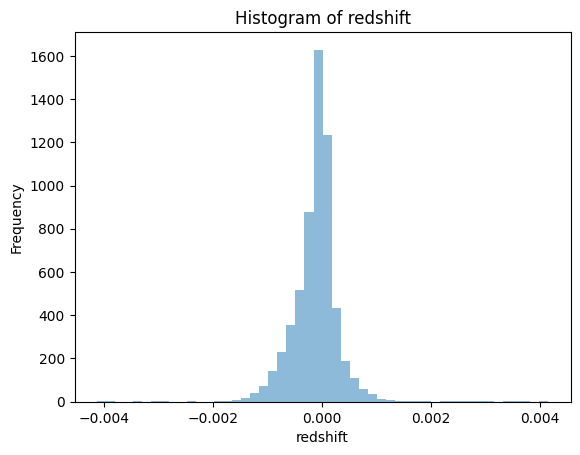

In [9]:
plt.hist(data[data['class'] == 'STAR']['redshift'], bins=50, alpha=0.5, density = True)
plt.title("Histogram of redshift")
plt.xlabel("redshift")
plt.ylabel("Frequency")
plt.show()

Nos encontramos ahora con múltiples variables categóricas que tienen demasiados resultados posibles y por lo tanto dificultan su análisis.
Estas son: run_ID, field_ID, plate y fiber_ID.
Plate representa el número de placa de titanio que se instala en el telescopio cuando se ve un sector del espacio determinado, hay 1 placa por cada sector del que se tomó datos, por lo que hay alrededor de 6000 placas. No solo este numero es extremo para una variable categórica sino que hay otras 2 variables  que ya nos proveen de datos sobre la locación en el espacio (alpha: ángulo de ascensión del telescopio; y delta: ángulo de declinación)
Fiber_ID es el id de las fibras que se conectan a esta placa, una por cada espectro detectado. Puede que, cuando observaciones se hacen en diferentes días, las fibras se conectan de forma distinta y un mismo ID termina perteneciendo a más de una observación de espectro de luz.
Fuente: https://www.sdss4.org/dr17/spectro/spectro_basics/

In [10]:
data = data.drop(['run_ID','fiber_ID','plate','field_ID','cam_col'], axis=1)

Convertimos ahora MJD a un formato de fecha gregoriano para despues transformar la variable a una columna de meses.

In [11]:
print(data['MJD'])

0        56354
1        58158
2        55592
3        58039
4        56187
         ...  
99995    57749
99996    56934
99997    54535
99998    56368
99999    57104
Name: MJD, Length: 100000, dtype: int64


In [12]:
data['Gregorian_Date'] = Time(data['MJD'], format='mjd').to_datetime()
data['Month'] = data['Gregorian_Date'].dt.month
data = data.drop(['Gregorian_Date'], axis=1)

Separamos el conjunto en entrenamiento y testeo, utilizando 80% de los datos para entrenamiento y 20% para testeo. Se setea un random state de 42 para mantener determinismo en la prueba y poder repetir los resultados.

In [13]:
# Split the data into training and testing sets
train_df, test_df = train_test_split(data, test_size=0.2, random_state=42)
# Print the shapes of the resulting DataFrames
print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

# Now you can work with train_df and test_df for training and evaluation

X_train = train_df.drop(['class'], axis=1)
y_train = train_df['class']
X_test = test_df.drop(['class'], axis=1)
y_test = test_df['class']

Training set shape: (80000, 11)
Testing set shape: (20000, 11)


In [14]:
numerical_cols = ["alpha", "delta", "u", "g", "r", "i", "z", "redshift", "Month"]
#categorical_cols = ["class", "cam_col"]

scaler = StandardScaler()

train_df_norm = scaler.fit_transform(X_train[numerical_cols])

test_df_norm = scaler.transform(X_test[numerical_cols])

In [17]:
import joblib
joblib.dump(scaler, "scaler.pkl")

#Log the scaler as an artifact
mlflow.log_artifact("scaler.pkl")

In [16]:
import boto3
# Create a boto3 session
session = boto3.Session(
    aws_access_key_id='minio',
    aws_secret_access_key='minio123'
)

# Configure AWS Wrangler to use MinIO endpoint
wr.config.s3_endpoint_url = 'http://localhost:9000'

# Then use the session
wr.s3.to_csv(
    df=data,
    path='s3://data/data.csv',
    index=False,
    boto3_session=session
)

{'paths': ['s3://data/data.csv'], 'partitions_values': {}}